# Практическое занятие №8: Машинное обучение с scikit-learn II

Классификация: логистическая регрессия, дерево решений, оценка по метрикам

## Задание

1. Загрузить указанный датасет.
2. Выполнить разбиение на обучающую (80%) и тестовую (20%) выборки с
```random_state=42``` и ```stratify=y```.
3. Построить логистическую регрессию и дерево решений.
4. Для дерева решений подобрать ограничивающие гиперпараметры (```max_depth```,
```min_samples_split```) для борьбы с переобучением.
5. Вычислить метрики: ```accuracy```, ```precision```, ```recall```, ```F1-score``` (для многоклассовой
классификации использовать ```average='macro'```).
6. Построить матрицы ошибок для обеих моделей.
7. Сравнить результаты и сделать вывод, какая модель лучше для данного датасета и
почему.
8. Оформить решение в Jupyter Notebook.

Вариант 10: Искусственные данные с нелинейной границей

- Датасет: ```make_moons(n_samples=500, noise=0.1, random_state=42)``` и
```make_circles(n_samples=500, noise=0.05, random_state=42)```

- Цель: Классификация объектов на двух наборах с нелинейной формой границы (два полумесяца и концентрические окружности).

- Особенность: Сравнить логистическую регрессию (линейная граница) и дерево решений (нелинейная граница) на этих двух типах данных. Визуализировать границы решений и сделать вывод о применимости каждого алгоритма.

## Выполнение работы

### Импорт библиотек

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.tree import DecisionTreeClassifier


### Загрузка/генерация датасетов

In [19]:
# Два полумесяца
X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.1,
    random_state=42
)

# Концентрические окружности
X_circles, y_circles = make_circles(
    n_samples=500,
    noise=0.05,
    random_state=42
)

### Первичный анализ данных

Для удобства анализа
numpy-массивы преобразуются в DataFrame.

In [20]:
# Создание DataFrame для moons
df_moons = pd.DataFrame(
    X_moons,
    columns=['feature_1', 'feature_2']
)

df_moons['target'] = y_moons

# Создание DataFrame для circles
df_circles = pd.DataFrame(
    X_circles,
    columns=['feature_1', 'feature_2']
)

df_circles['target'] = y_circles


# Размер datasets
print("Moons размер:", df_moons.shape)
print("Circles размер:", df_circles.shape)

# Первые строки datasets
print("\nMoons первые 5 строк:")
print(df_moons.head())

print("\nCircles первые 5 строк:")
print(df_circles.head())

# Информация о данных
print("\nMoons информация:")
print(df_moons.info())

print("\nCircles информация:")
print(df_circles.info())

# Статистическое описание
print("\nMoons описание:")
print(df_moons.describe())

print("\nCircles описание:")
print(df_circles.describe())

# Распределение классов
print("\nMoons распределение:")
print(df_moons['target'].value_counts())

print("\nCircles распределение:")
print(df_circles['target'].value_counts())

Moons размер: (500, 3)
Circles размер: (500, 3)

Moons первые 5 строк:
   feature_1  feature_2  target
0   0.830676  -0.409936       1
1   0.798355   0.837612       0
2   1.050468  -0.485162       1
3  -0.258143   0.980008       0
4   0.330682   1.147633       0

Circles первые 5 строк:
   feature_1  feature_2  target
0  -0.750896   0.313511       1
1  -0.164164   0.986075       0
2  -0.771359   0.027513       1
3  -0.670347  -0.657977       0
4  -0.826468   0.594071       0

Moons информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  500 non-null    float64
 1   feature_2  500 non-null    float64
 2   target     500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB
None

Circles информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column     

Были сгенерированы два датасета: make_moons и make_circles.
Оба набора данных содержат по 500 объектов и по 2 признака.
Пропуски отсутствуют, типы данных корректны, а классы распределены равномерно.

### Визуализация датасетов

Для лучшего понимания структуры данных была выполнена визуализация обоих датасетов.
Разные цвета соответствуют разным классам объектов.

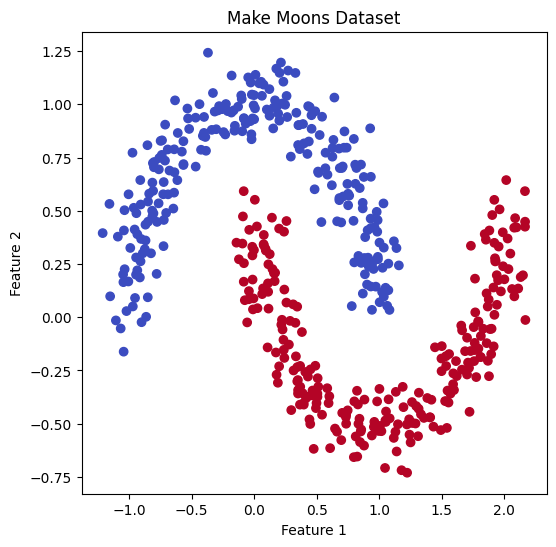

In [23]:
plt.figure(figsize=(6,6))

plt.scatter(
    X_moons[:,0],
    X_moons[:,1],
    c=y_moons,
    cmap='coolwarm'
)

plt.title('Make Moons Dataset')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.show()

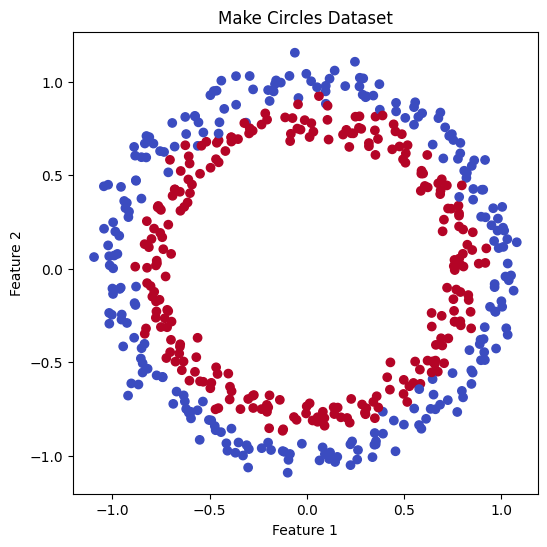

In [24]:
plt.figure(figsize=(6,6))

plt.scatter(
    X_circles[:,0],
    X_circles[:,1],
    c=y_circles,
    cmap='coolwarm'
)

plt.title('Make Circles Dataset')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.show()

На графиках видно, что классы имеют нелинейную форму границы.
В датасете ```make_moons``` классы представлены в виде двух полумесяцев, а в ```make_circles``` - в виде вложенных окружностей.

### Разделение данных на признаки и целевую переменную (таргет)

Данные разделяются на:
- X — признаки;
- y — целевую переменную.

После этого выполняется разделение на обучающую и тестовую выборки.

In [31]:
# Признаки и target для moons
X_moons_data = df_moons[
    ['feature_1', 'feature_2']
]

y_moons_data = df_moons['target']

# Разделение moons на train/test
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons_data,
    y_moons_data,
    test_size=0.2,
    random_state=42,
    stratify=y_moons_data
)

# Признаки и target для circles
X_circles_data = df_circles[
    ['feature_1', 'feature_2']
]

y_circles_data = df_circles['target']


# Разделение circles на train/test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_circles_data,
    y_circles_data,
    test_size=0.2,
    random_state=42,
    stratify=y_circles_data
)

print("Moons train shape:", X_train_m.shape)
print("Moons test shape:", X_test_m.shape)

print("\nCircles train shape:", X_train_c.shape)
print("Circles test shape:", X_test_c.shape)

Moons train shape: (400, 2)
Moons test shape: (100, 2)

Circles train shape: (400, 2)
Circles test shape: (100, 2)


Данные были разделены на обучающую и тестовую выборки в соотношении 80/20.

Параметр stratify позволил сохранить баланс классов в обеих выборках.

### Масштабирование данных moons и circles для логистической регрессии

In [34]:
# Масштабирование circles
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

# Масштабирование circles
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

Для логистической регрессии было выполнено масштабирование признаков с помощью ```StandardScaler```,
так как алгоритм чувствителен к масштабу данных.

### Logistic Regression (Moons)

Логистическая регрессия — это линейный алгоритм классификации, который пытается разделить классы с помощью линейной границы.

In [ ]:
# Создание модели
model_lr_m = LogisticRegression(
    random_state=42
)

# Обучение
model_lr_m.fit(
    X_train_m_scaled,
    y_train_m
)

# Предсказание
y_pred_lr_m = model_lr_m.predict(
    X_test_m_scaled
)

Расчет метрик качества:

In [40]:
# Метрики качества
accuracy_lr_m = accuracy_score(
    y_test_m,
    y_pred_lr_m
)

precision_lr_m = precision_score(
    y_test_m,
    y_pred_lr_m
)

recall_lr_m = recall_score(
    y_test_m,
    y_pred_lr_m
)

f1_lr_m = f1_score(
    y_test_m,
    y_pred_lr_m
)

print("=== Logistic Regression: Moons ===")

print(f"Accuracy: {accuracy_lr_m:.3f}")
print(f"Precision: {precision_lr_m:.3f}")
print(f"Recall: {recall_lr_m:.3f}")
print(f"F1-score: {f1_lr_m:.3f}")

=== Logistic Regression: Moons ===
Accuracy: 0.860
Precision: 0.821
Recall: 0.920
F1-score: 0.868


Логистическая регрессия показала достаточно хорошее качество на датасете ```make_moons```.

Accuracy = 0.860 означает, что модель правильно классифицировала около 86% объектов.

Recall = 0.920 является высоким, что говорит о том, что модель хорошо обнаруживает объекты класса 1.

Однако precision = 0.821 ниже,что указывает на наличие ложноположительных предсказаний.

В целом модель работает неплохо, но из-за нелинейной формы данных логистическая регрессия допускает ошибки.

### Построение матрицы ошибок для moons (Logistic Regression)

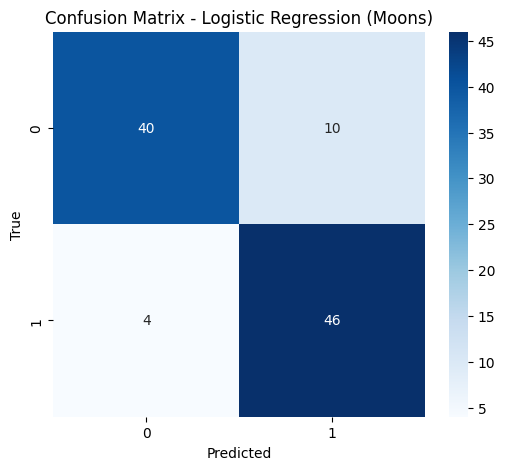

In [71]:
cm_lr_m = confusion_matrix(
    y_test_m,
    y_pred_lr_m
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr_m,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.title(
    'Confusion Matrix - Logistic Regression (Moons)'
)

plt.show()

Матрица ошибок показывает, что модель правильно классифицировала:
- 40 объектов класса 0;
- 46 объектов класса 1.

При этом наблюдаются:
- 10 ложноположительных ошибок (FP);
- 4 ложноотрицательные ошибки (FN).

Количество FP больше, чем FN, что говорит о том, что модель чаще ошибочно относит объекты к классу 1.

### Logistic Regression (Circles)

In [43]:
# Создание модели
model_lr_c = LogisticRegression(
    random_state=42
)

# Обучение модели
model_lr_c.fit(
    X_train_c_scaled,
    y_train_c
)

# Предсказание
y_pred_lr_c = model_lr_c.predict(
    X_test_c_scaled
)

Расчет метрик качества:

In [46]:
# Метрики качества
accuracy_lr_c = accuracy_score(
    y_test_c,
    y_pred_lr_c
)

precision_lr_c = precision_score(
    y_test_c,
    y_pred_lr_c
)

recall_lr_c = recall_score(
    y_test_c,
    y_pred_lr_c
)

f1_lr_c = f1_score(
    y_test_c,
    y_pred_lr_c
)

# Вывод метрик

print("=== Logistic Regression: Circles ===")

print(f"Accuracy: {accuracy_lr_c:.3f}")
print(f"Precision: {precision_lr_c:.3f}")
print(f"Recall: {recall_lr_c:.3f}")
print(f"F1-score: {f1_lr_c:.3f}")

=== Logistic Regression: Circles ===
Accuracy: 0.430
Precision: 0.422
Recall: 0.380
F1-score: 0.400


Логистическая регрессия показала низкое качество на датасете make_circles.

Accuracy = 0.430 означает, что модель правильно классифицировала только около 43% объектов.

Низкие значения precision, recall и F1-score показывают, что модель плохо разделяет классы.

Это связано с тем, что логистическая регрессия строит линейную границу, тогда как данные make_circles имеют сложную нелинейную структуру в виде вложенных окружностей.

### Построение матрицы ошибок для circles (Logistic Regression)

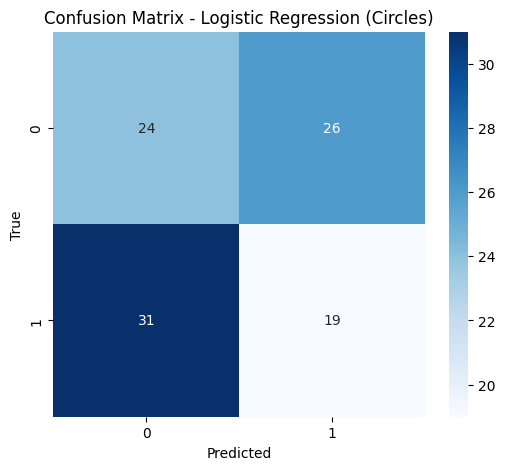

In [70]:
# Матрица ошибок
cm_lr_c = confusion_matrix(
    y_test_c,
    y_pred_lr_c
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr_c,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.title(
    'Confusion Matrix - Logistic Regression (Circles)'
)

plt.show()

Матрица ошибок показывает, что модель допустила большое количество ошибок при классификации объектов.

Правильно были определены:
- 24 объекта класса 0;
- 19 объектов класса 1.

При этом количество ошибок является высоким:
- 26 ложноположительных предсказаний (FP);
- 31 ложноотрицательное предсказание (FN).

Это подтверждает, что логистическая регрессия плохо справляется с разделением классов на датасете make_circles.

### Decision Tree

Дерево решений — это нелинейный алгоритм классификации, который способен строить сложные границы разделения классов.

Для борьбы с переобучением используются ограничения глубины дерева и минимального количества объектов для разбиения.

### Decision Tree (Moons)

In [52]:
# Создание модели дерева решений
model_dt_m = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

# Обучение дерева
model_dt_m.fit(
    X_train_m,
    y_train_m
)

# Предсказание
y_pred_dt_m = model_dt_m.predict(
    X_test_m
)

Расчет метрик для moons:

In [54]:
# Метрики качества
accuracy_dt_m = accuracy_score(
    y_test_m,
    y_pred_dt_m
)

precision_dt_m = precision_score(
    y_test_m,
    y_pred_dt_m
)

recall_dt_m = recall_score(
    y_test_m,
    y_pred_dt_m
)

f1_dt_m = f1_score(
    y_test_m,
    y_pred_dt_m
)

# ВЫвод метрик
print("=== Decision Tree: Moons ===")
print(f"Accuracy: {accuracy_dt_m:.3f}")
print(f"Precision: {precision_dt_m:.3f}")
print(f"Recall: {recall_dt_m:.3f}")
print(f"F1-score: {f1_dt_m:.3f}")

=== Decision Tree: Moons ===
Accuracy: 0.980
Precision: 0.980
Recall: 0.980
F1-score: 0.980


Дерево решений показало очень высокое качество на датасете make_moons.

Все основные метрики (accuracy, precision, recall и F1-score) имеют значение 0.980, что говорит о практически идеальной классификации объектов.

Это связано с тем, что дерево решений способно строить нелинейные границы разделения, которые хорошо подходят для структуры данных make_moons.

### Построение матрицы ошибок для moons (Decision Tree)

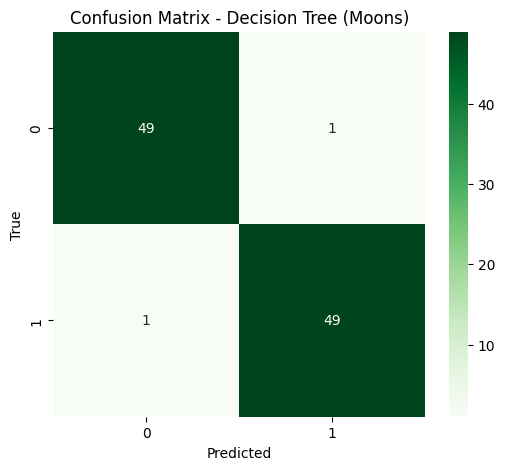

In [69]:
cm_dt_m = confusion_matrix(
    y_test_m,
    y_pred_dt_m
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt_m,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.title(
    'Confusion Matrix - Decision Tree (Moons)'
)

plt.show()

Матрица ошибок показывает, что модель почти не допускает ошибок.

Правильно были классифицированы:
- 49 объектов класса 0;
- 49 объектов класса 1.

Модель допустила всего:
- 1 ложноположительную ошибку (FP);
- 1 ложноотрицательную ошибку (FN).

Это подтверждает, что дерево решений значительно лучше справляется с нелинейной структурой данных, чем логистическая регрессия.

### Decision Tree (Circles)

In [58]:
# Создание модели дерева решений
model_dt_c = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

# Обучение модели
model_dt_c.fit(
    X_train_c,
    y_train_c
)

# Предсказание
y_pred_dt_c = model_dt_c.predict(
    X_test_c
)

Расчет метрик:

In [61]:
# Метрики качества
accuracy_dt_c = accuracy_score(
    y_test_c,
    y_pred_dt_c
)

precision_dt_c = precision_score(
    y_test_c,
    y_pred_dt_c
)

recall_dt_c = recall_score(
    y_test_c,
    y_pred_dt_c
)

f1_dt_c = f1_score(
    y_test_c,
    y_pred_dt_c
)

# Вывод метрик
print("=== Decision Tree: Circles ===")
print(f"Accuracy: {accuracy_dt_c:.3f}")
print(f"Precision: {precision_dt_c:.3f}")
print(f"Recall: {recall_dt_c:.3f}")
print(f"F1-score: {f1_dt_c:.3f}")

=== Decision Tree: Circles ===
Accuracy: 0.800
Precision: 0.742
Recall: 0.920
F1-score: 0.821


Дерево решений показало хорошее качество
на датасете make_circles.

Accuracy = 0.800 означает, что модель правильно классифицировала около 80% объектов.

Высокое значение recall = 0.920 показывает, что модель хорошо обнаруживает объекты класса 1.

При этом precision = 0.742 ниже, что говорит о наличии ложноположительных ошибок.

В целом дерево решений справилось с задачей значительно лучше, чем логистическая регрессия, так как способно строить нелинейные границы разделения.

### Построение матрицы ошибок для circles (Decision Tree)

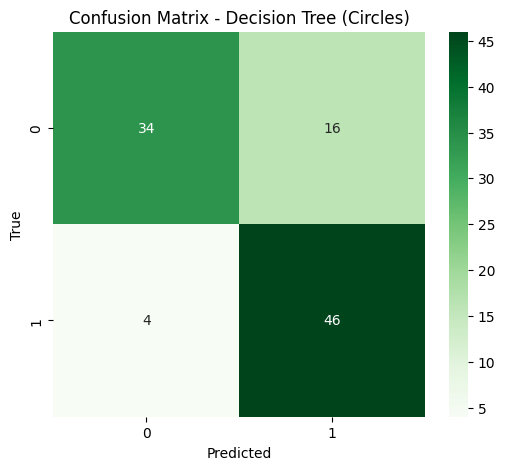

In [68]:
# Матрица ошибок

cm_dt_c = confusion_matrix(
    y_test_c,
    y_pred_dt_c
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt_c,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.title(
    'Confusion Matrix - Decision Tree (Circles)'
)

plt.show()

Матрица ошибок показывает, что модель правильно классифицировала:
- 34 объекта класса 0;
- 46 объектов класса 1.

При этом модель допустила:
- 16 ложноположительных ошибок (FP);
- 4 ложноотрицательные ошибки (FN).

Количество ошибок значительно меньше, чем у логистической регрессии, что подтверждает более высокое качество дерева решений на датасете make_circles.

### Сравнение моделей. Построение таблицы сравнения

Строим таблицу сравнения моделей Logistic Regression и Decesion Tree

In [63]:
# Таблица сравнения моделей

comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression (Moons)',
        'Decision Tree (Moons)',
        'Logistic Regression (Circles)',
        'Decision Tree (Circles)'
    ],

    'Accuracy': [
        accuracy_lr_m,
        accuracy_dt_m,
        accuracy_lr_c,
        accuracy_dt_c
    ],

    'Precision': [
        precision_lr_m,
        precision_dt_m,
        precision_lr_c,
        precision_dt_c
    ],

    'Recall': [
        recall_lr_m,
        recall_dt_m,
        recall_lr_c,
        recall_dt_c
    ],

    'F1-score': [
        f1_lr_m,
        f1_dt_m,
        f1_lr_c,
        f1_dt_c
    ]
})

print(comparison)

                           Model  Accuracy  Precision  Recall  F1-score
0    Logistic Regression (Moons)      0.86   0.821429    0.92  0.867925
1          Decision Tree (Moons)      0.98   0.980000    0.98  0.980000
2  Logistic Regression (Circles)      0.43   0.422222    0.38  0.400000
3        Decision Tree (Circles)      0.80   0.741935    0.92  0.821429


В ходе работы были исследованы две модели классификации:
- логистическая регрессия;
- дерево решений.

Модели были протестированы на двух искусственных датасетах с нелинейной структурой:
- ```make_moons``` ;
- ```make_circles```.

Логистическая регрессия показала хорошие результаты на ```make_moons```, однако значительно хуже справилась с ```make_circles```, так как алгоритм использует линейную границу разделения.

Дерево решений показало более высокое качество на обоих датасетах, поскольку способно строить нелинейные границы классификации.

Наилучший результат был получен деревом решений на датасете ```make_moons```.

Таким образом, для задач с нелинейной структурой данных дерево решений является более подходящим алгоритмом,
чем логистическая регрессия.

### Визуализация границ решений

In [76]:
# Функция для отрисовки границы решений

def plot_decision_boundary(
    model,
    X,
    y,
    ax,
    title
):

    x_min, x_max = (
        X[:, 0].min() - 1,
        X[:, 0].max() + 1
    )

    y_min, y_max = (
        X[:, 1].min() - 1,
        X[:, 1].max() + 1
    )

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    Z = model.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap='coolwarm'
    )

    ax.scatter(
        X[:,0],
        X[:,1],
        c=y,
        cmap='coolwarm',
        edgecolors='k'
    )

    ax.set_title(title)

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

Для наглядного сравнения моделей были построены границы решений для логистической регрессии и дерева решений на датасетах make_moons и make_circles.

/home/ub/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/ub/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


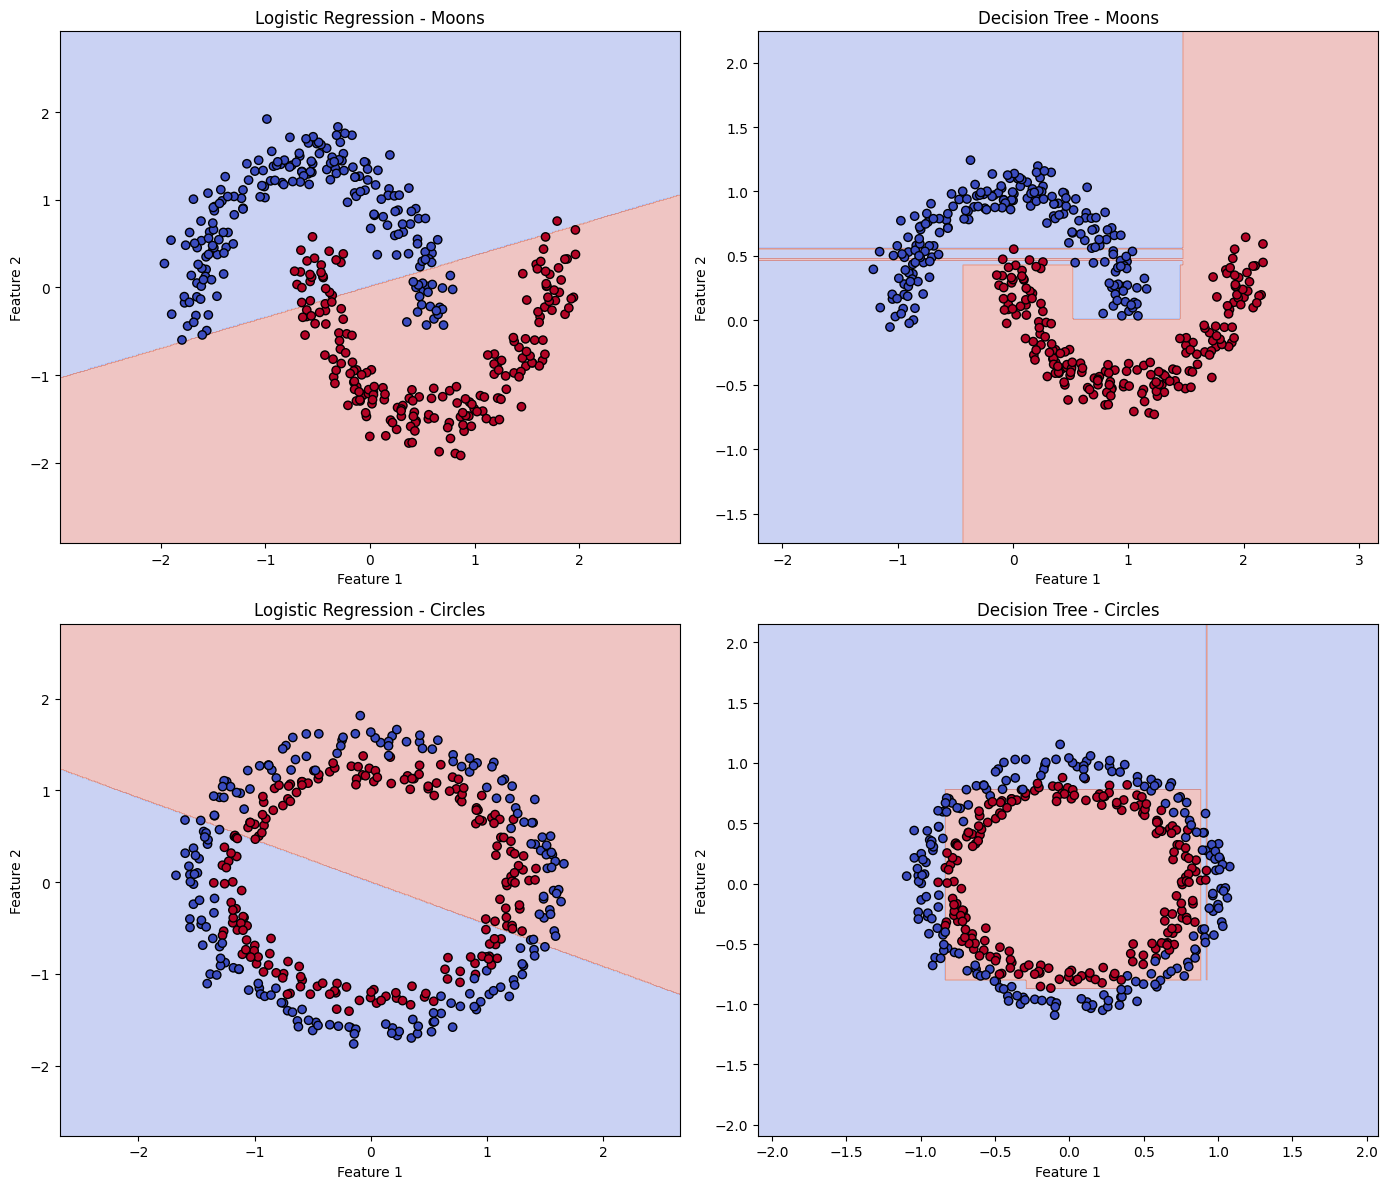

In [77]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 12)
)

# Визуализация Logistic Regression - Moons

plot_decision_boundary(
    model_lr_m,
    X_train_m_scaled,
    y_train_m,
    axes[0,0],
    'Logistic Regression - Moons'
)

# Визуализация Decision Tree - Moons

plot_decision_boundary(
    model_dt_m,
    X_train_m.values,
    y_train_m,
    axes[0,1],
    'Decision Tree - Moons'
)

# Визуализация Logistic Regression - Circles

plot_decision_boundary(
    model_lr_c,
    X_train_c_scaled,
    y_train_c,
    axes[1,0],
    'Logistic Regression - Circles'
)

# Визуализация Decision Tree - Circles

plot_decision_boundary(
    model_dt_c,
    X_train_c.values,
    y_train_c,
    axes[1,1],
    'Decision Tree - Circles'
)

plt.tight_layout()

plt.show()

### Общий вывод

Визуализация показывает,
что логистическая регрессия строит только линейную границу разделения,
поэтому плохо подходит для данных
со сложной нелинейной структурой.

На датасете make_moons модель ещё частично разделяет классы,
однако на ```make_circles``` линейная граница практически не соответствует форме данных.

Дерево решений строит более гибкие нелинейные границы,
что позволяет значительно точнее разделять объекты обоих классов.

Особенно заметно преимущество дерева решений перед линейной регрессией на датасете ```make_circles```,
где модель смогла выделить внутреннюю окружность и показать более высокое качество классификации.

Но наилучший результат был получен деревом решений на датасете ```make_moons```. Потому что он имеет:
- accuracy = 0.980;
- практически идеальную confusion matrix (всего 2 ошибки.).


Таким образом, для задач с нелинейной структурой данных дерево решений является более подходящим алгоритмом,
чем логистическая регрессия.